# Ciencia de datos aplicada (ITBA): Modelo de tercer entregable

**Entrenamiento y validación de Modelos de Machine Learning**

**Equipo:** Patrick Luca Torlaschi (62273), Candela Silva Diniz (63402)

**Nombre del proyecto**: Modelo Predictivo de Seguridad Ciudadana



---
## Descripción del enfoque adoptado y su justificación

Partiendo del dataset enriquecido y limpio construido en la entrega anterior (delitos de la Ciudad de Buenos Aires, 2023), planteamos **dos enfoques complementarios de aprendizaje supervisado** sobre el mismo conjunto de datos:

1. **Regresión** — predecir la **cantidad** de delitos asociada a una combinación de contexto espacio-temporal (barrio, comuna, tipo, turno, día de semana, feriado, etc.). Es fiel a la variable objetivo original (`cantidad`) definida al agrupar los registros en la segunda entrega.

2. **Clasificación** — derivada del mismo target: identificar combinaciones de **alto vs. bajo riesgo**, binarizando `cantidad` por su mediana. Permite una lectura operativa (¿dónde y cuándo es probable que se concentren los delitos?).

**Justificación.** El problema de seguridad ciudadana admite ambas lecturas: la regresión cuantifica la magnitud esperada y la clasificación entrega una señal accionable de priorización. Usar el mismo dataset enriquecido para los dos enfoques nos permite comparar técnicas (Random Forest, Gradient Boosting, SVM), validar con métricas propias de cada tipo de tarea y persistir el mejor modelo de cada uno para la integración del siguiente entregable.


---
## Carga de librerias y Dataset a utilizar

### Carga Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import requests

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# estilo
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42

### Carga DataSet Entrega 2
Reproducimos el flujo de la etapa anterior (curado y pre-procesamiento) descargando el dataset desde Google Drive con `gdown` y regenerando el dataset enriquecido `df_grouped`. De este modo el notebook corre de punta a punta.

#### Carga Dataset Base

In [2]:
import re

def get_drive_id(url):
    match = re.search(r'/d/([a-zA-Z0-9_-]+)/view', url)
    if match:
        return match.group(1)
    return None

fuentes = {
    2023: 'https://drive.google.com/file/d/1k37a1VSwADySQCXtK579IcCd05egPbyE/view?usp=sharing',
    2022: 'https://drive.google.com/file/d/1UzPX1W4HUakyvjJ1uBayLJjyoGJ3u0YQ/view?usp=sharing',
}

# Update URLs to correct gdown format
fuentes_corrected = {}
for anio, url in fuentes.items():
    file_id = get_drive_id(url)
    if file_id:
        fuentes_corrected[anio] = f'https://drive.google.com/uc?id={file_id}'
    else:
        fuentes_corrected[anio] = url # Keep original if ID extraction fails

fuentes = fuentes_corrected

dfs = []
for anio, url in fuentes.items():
    archivo = f'delitos_{anio}.csv'
    if url:
        gdown.download(url, archivo, quiet=False)
    di = pd.read_csv(archivo, dtype={'barrio': str, 'comuna': str})
    print(f'{anio}: {di.shape[0]} registros')
    dfs.append(di)

df = pd.concat(dfs, ignore_index=True)
df = df.drop(columns=['id-mapa'])
print('Total combinado:', df.shape)
print(df['anio'].value_counts())
df.head()

Downloading...
From: https://drive.google.com/uc?id=1k37a1VSwADySQCXtK579IcCd05egPbyE
To: /Users/patricktoralschi/Desktop/ciencia-datos/delitos_2023.csv
100%|██████████| 19.8M/19.8M [00:01<00:00, 17.6MB/s]


2023: 155897 registros


Downloading...
From: https://drive.google.com/uc?id=1UzPX1W4HUakyvjJ1uBayLJjyoGJ3u0YQ
To: /Users/patricktoralschi/Desktop/ciencia-datos/delitos_2022.csv
100%|██████████| 16.8M/16.8M [00:00<00:00, 19.4MB/s]


2022: 140918 registros
Total combinado: (296815, 14)
anio
2023    155897
2022    140918
Name: count, dtype: int64


,anio,mes,dia,fecha,franja,tipo,subtipo,uso_arma,uso_moto,barrio,comuna,latitud,longitud,cantidad
0,2023,ENERO,DOMINGO,2023-01-01,1.0,Amenazas,Amenazas,NO,NO,NaN,NaN,0.0,0.0,1
1,2023,ENERO,LUNES,2023-01-02,12.0,Amenazas,Amenazas,NO,NO,NaN,NaN,0.0,0.0,1
2,2023,ENERO,MARTES,2023-01-03,7.0,Amenazas,Amenazas,NO,NO,NaN,NaN,0.0,0.0,1
3,2023,ENERO,MARTES,2023-01-03,21.0,Amenazas,Amenazas,NO,NO,NaN,NaN,0.0,0.0,1
4,2023,ENERO,MARTES,2023-01-03,12.0,Amenazas,Amenazas,NO,NO,NaN,NaN,0.0,0.0,1


#### Limpieza y Preprocesado de datos

In [3]:
df_transformed = df.drop(columns=['dia', 'cantidad']).copy()  # conservamos 'anio' como feature

df_transformed['fecha'] = pd.to_datetime(df_transformed['fecha'])
df_transformed['dia_semana'] = df_transformed['fecha'].dt.dayofweek
df_transformed['latitud'] = pd.to_numeric(df_transformed['latitud'], errors='coerce').replace(0.0, np.nan)
df_transformed['longitud'] = pd.to_numeric(df_transformed['longitud'], errors='coerce').replace(0.0, np.nan)

df_transformed['uso_arma'] = df_transformed['uso_arma'].map({'SI': True, 'NO': False})
df_transformed['uso_moto'] = df_transformed['uso_moto'].map({'SI': True, 'NO': False})

for col in ['mes', 'tipo', 'subtipo', 'barrio']:
    df_transformed[col] = df_transformed[col].str.strip().str.title()

meses = {'Enero':1,'Febrero':2,'Marzo':3,'Abril':4,'Mayo':5,'Junio':6,
         'Julio':7,'Agosto':8,'Septiembre':9,'Octubre':10,'Noviembre':11,'Diciembre':12}
df_transformed['mes_num'] = df_transformed['mes'].map(meses)

def franja_a_turno(h):
    if pd.isna(h): return np.nan
    if 6 <= h < 12:  return 'Mañana'
    if 12 <= h < 18: return 'Tarde'
    if 18 <= h < 24: return 'Noche'
    return 'Madrugada'

df_transformed['turno'] = df_transformed['franja'].apply(franja_a_turno)
df_transformed['es_fin_de_semana'] = df_transformed['fecha'].dt.dayofweek >= 5

gravedad = {'Amenazas':1,'Lesiones':2,'Vialidad':3,'Hurto':4,'Robo':5,'Homicidios':6}
df_transformed['gravedad'] = df_transformed['tipo'].map(gravedad)

df_transformed = df_transformed[
    df_transformed['latitud'].notna() &
    df_transformed['longitud'].notna() &
    df_transformed['barrio'].notna() &
    df_transformed['comuna'].notna() &
    df_transformed['turno'].notna()      # descarta franjas nulas (evita la categoría espuria turno_nan)
].copy()

def get_ar_holidays_full(year: int) -> dict:
    url = f"https://api.argentinadatos.com/v1/feriados/{year}"
    response = requests.get(url)
    response.raise_for_status()
    return {h['fecha']: h['nombre'] for h in response.json()}

# Feriados de TODOS los años presentes en los datos (las claves son fechas completas YYYY-MM-DD)
ar_holidays_full = {}
for a in sorted(df_transformed['anio'].unique()):
    try:
        ar_holidays_full.update(get_ar_holidays_full(int(a)))
    except Exception as e:
        print(f'No se pudo consultar feriados de {a}, se continúa sin ellos:', e)

df_transformed['es_feriado'] = df_transformed['fecha'].dt.strftime('%Y-%m-%d').isin(ar_holidays_full)
df_transformed['nombre_feriado'] = df_transformed['fecha'].dt.strftime('%Y-%m-%d').map(ar_holidays_full).fillna('')

# Pares espaciales válidos: cada barrio pertenece a una única comuna
barrio_comuna = df_transformed[['barrio', 'comuna']].drop_duplicates()

# Contextos temporales que realmente existieron en el calendario de cada año presente
# (incluye 'anio' y mantiene coherentes dia_semana<->es_fin_de_semana y mes_num<->es_feriado)
contexto_temporal = df_transformed[
    ['anio', 'dia_semana', 'mes_num', 'es_fin_de_semana', 'es_feriado']
].drop_duplicates()

turnos_df = pd.DataFrame({'turno': df_transformed['turno'].unique()})

# Grilla de contextos posibles = (barrio, comuna) x (contexto temporal por año) x (turno)
df_full = (barrio_comuna
           .merge(contexto_temporal, how='cross')
           .merge(turnos_df, how='cross'))

group_cols = ['barrio','comuna','anio','dia_semana','mes_num','turno','es_fin_de_semana','es_feriado']
df_full = df_full[group_cols]

df_real = df_transformed.groupby(group_cols).size().reset_index(name='cantidad')

df_final = df_full.merge(df_real, on=group_cols, how='left')

df_final['cantidad'] = df_final['cantidad'].fillna(0)

print('Dataset enriquecido (df_final):', df_final.shape)
df_final.head()

Dataset enriquecido (df_final): (40768, 9)


,barrio,comuna,anio,dia_semana,mes_num,turno,es_fin_de_semana,es_feriado,cantidad
0,Boca,4,2023,3,11,Tarde,False,False,20.0
1,Boca,4,2023,3,11,Noche,False,False,14.0
2,Boca,4,2023,3,11,Mañana,False,False,10.0
3,Boca,4,2023,3,11,Madrugada,False,False,5.0
4,Boca,4,2023,1,8,Tarde,False,False,15.0


---
## Preparacion de Variables para el modelado
Seleccionamos las variables predictoras evitando *fugas de información*: descartamos `fecha` (identificador temporal exacto), `nombre_feriado` (redundante con `es_feriado`) y `mes` en texto (ya codificado en `mes_num`). Incorporamos `anio` como variable para capturar la variación interanual cuando el dataset reúne más de un año. Tratamos las categóricas con *One-Hot Encoding* dentro de un `Pipeline` para que la transformación viaje junto al modelo al persistirlo.

In [4]:
features = ['barrio','comuna','anio','dia_semana','mes_num','turno','es_fin_de_semana','es_feriado']

categoricas = ['barrio', 'comuna', 'turno']
numericas   = ['anio', 'dia_semana', 'mes_num', 'es_fin_de_semana', 'es_feriado']

X = df_final[features].copy()
y_reg = df_final['cantidad'].copy()                    # target de regresión

# Target de clasificación: alto/bajo riesgo respecto de la mediana de cantidad
umbral = df_final['cantidad'].median()
y_clf = (df_final['cantidad'] > umbral).astype(int)    # 1 = alto riesgo
print('Umbral (mediana de cantidad):', umbral)
print('Distribución de clases (clasificación):')
print(y_clf.value_counts(normalize=True).round(3))

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
        ('num', StandardScaler(), numericas)
    ],
    remainder='passthrough'
)

Umbral (mediana de cantidad): 4.0
Distribución de clases (clasificación):
cantidad
0    0.507
1    0.493
Name: proportion, dtype: float64


In [5]:
from sklearn.inspection import permutation_importance

preprocessor_dense = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categoricas),
    ],
    remainder='passthrough'
)

---
## Enfoque 1 — Regresión: predecir la *cantidad* de delitos

Entrenamos y validamos modelos con búsqueda de hiperparámetros (`GridSearchCV`, validación cruzada). Comparamos **Random Forest Regressor**, **Gradient Boosting Regressor** y un **HistGradientBoosting con pérdida de Poisson** (apropiado para datos de conteo, con predicciones no negativas).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
) # Se usa 20% para testing
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (32614, 8)  Test: (8154, 8)


### Entrenamiento con Random Forest Regressor

In [7]:
from sklearn.ensemble import RandomForestRegressor

pipe_rf = Pipeline([('prep', preprocessor),
                    ('model', RandomForestRegressor(random_state=RANDOM_STATE))])

param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3,
                       scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print('Mejores hiperparámetros (RF Regressor):', grid_rf.best_params_)
print('MAE CV (train):', -grid_rf.best_score_)

Mejores hiperparámetros (RF Regressor): {'model__max_depth': 20, 'model__n_estimators': 200}
MAE CV (train): 2.5929739001582863


### Entrenamiento con Gradient Boosting Regressor

In [8]:
from sklearn.ensemble import GradientBoostingRegressor

pipe_gb = Pipeline([('prep', preprocessor),
                    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))])

param_grid_gb = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [3, 5]
}

grid_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=3,
                       scoring='neg_mean_absolute_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print('Mejores hiperparámetros (Gradient Boosting):', grid_gb.best_params_)
print('MAE CV (train):', -grid_gb.best_score_)

Mejores hiperparámetros (Gradient Boosting): {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
MAE CV (train): 2.3830661181326884


### Entrenamiento con HistGradientBoosting (pérdida de Poisson)


In [9]:
from sklearn.ensemble import HistGradientBoostingRegressor

pipe_hgb = Pipeline([('prep', preprocessor_dense),
                     ('model', HistGradientBoostingRegressor(
                         loss='poisson', random_state=RANDOM_STATE,
                         early_stopping=True, validation_fraction=0.1))])

param_grid_hgb = {
    'model__learning_rate':    [0.05, 0.1],
    'model__max_leaf_nodes':   [31, 63],
    'model__max_iter':         [300, 600],
    'model__l2_regularization':[0.0, 1.0],
}

grid_hgb = GridSearchCV(pipe_hgb, param_grid_hgb, cv=3,
                        scoring='neg_mean_absolute_error', n_jobs=-1)
grid_hgb.fit(X_train, y_train)
print('Mejores hiperparámetros (HistGB Poisson):', grid_hgb.best_params_)
print('MAE CV (train):', -grid_hgb.best_score_)

Mejores hiperparámetros (HistGB Poisson): {'model__l2_regularization': 1.0, 'model__learning_rate': 0.1, 'model__max_iter': 300, 'model__max_leaf_nodes': 63}
MAE CV (train): 2.2034637952083522


### Comparación y selección del modelo de regresión

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluar_reg(modelo, nombre):
    # la cantidad de delitos es un conteo >= 0: recortamos a 0 las predicciones negativas
    pred = np.clip(modelo.predict(X_test), 0, None)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Todos los candidatos de regresión (incluye el nuevo HistGB Poisson)
modelos_reg = {
    'Random Forest':     grid_rf.best_estimator_,
    'Gradient Boosting': grid_gb.best_estimator_,
    'HistGB Poisson':    grid_hgb.best_estimator_,
}

resultados_reg = pd.DataFrame(
    [evaluar_reg(m, n) for n, m in modelos_reg.items()]
).set_index('Modelo').round(4)
print(resultados_reg)

mejor_nombre_reg = resultados_reg['MAE'].idxmin()
mejor_modelo_reg = modelos_reg[mejor_nombre_reg]
print(f'\nModelo de regresión seleccionado: {mejor_nombre_reg}')

                      MAE    RMSE      R2
Modelo                                   
Random Forest      2.6142  4.0620  0.7723
Gradient Boosting  2.4116  3.8135  0.7993
HistGB Poisson     2.2250  3.4935  0.8316

Modelo de regresión seleccionado: HistGB Poisson


Exception ignored in: <function ResourceTracker.__del__ at 0x1048baac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes


### Visualización del modelo de regresión seleccionado

Exception ignored in: <function ResourceTracker.__del__ at 0x107ba2ac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10444aac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-n

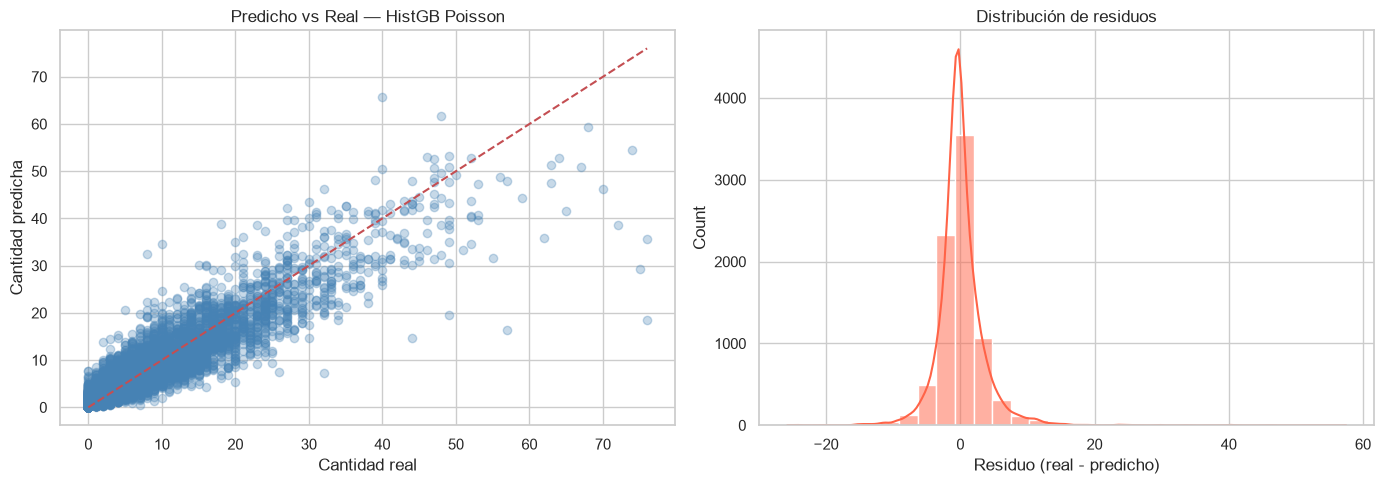

Exception ignored in: <function ResourceTracker.__del__ at 0x12014eac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1058eaac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-n

In [11]:
y_pred_reg = np.clip(mejor_modelo_reg.predict(X_test), 0, None)  # conteo no negativo

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicho vs Real
axes[0].scatter(y_test, y_pred_reg, alpha=0.3, color='steelblue')
lim = [y_test.min(), y_test.max()]
axes[0].plot(lim, lim, 'r--')
axes[0].set_xlabel('Cantidad real')
axes[0].set_ylabel('Cantidad predicha')
axes[0].set_title(f'Predicho vs Real — {mejor_nombre_reg}')

# Distribución de residuos
residuos = y_test - y_pred_reg
sns.histplot(residuos, bins=30, kde=True, ax=axes[1], color='tomato')
axes[1].set_xlabel('Residuo (real - predicho)')
axes[1].set_title('Distribución de residuos')

plt.tight_layout()
plt.show()

### Patrón espacio-temporal: real vs. predicho
Comparamos el mapa de calor de delitos promedio por comuna y turno **real** contra el **predicho** por el modelo de regresión (sobre el test, misma escala de color). Si ambos mapas se parecen, el modelo está capturando correctamente *dónde* y *cuándo* se concentra la criminalidad, más allá del error puntual por bloque.

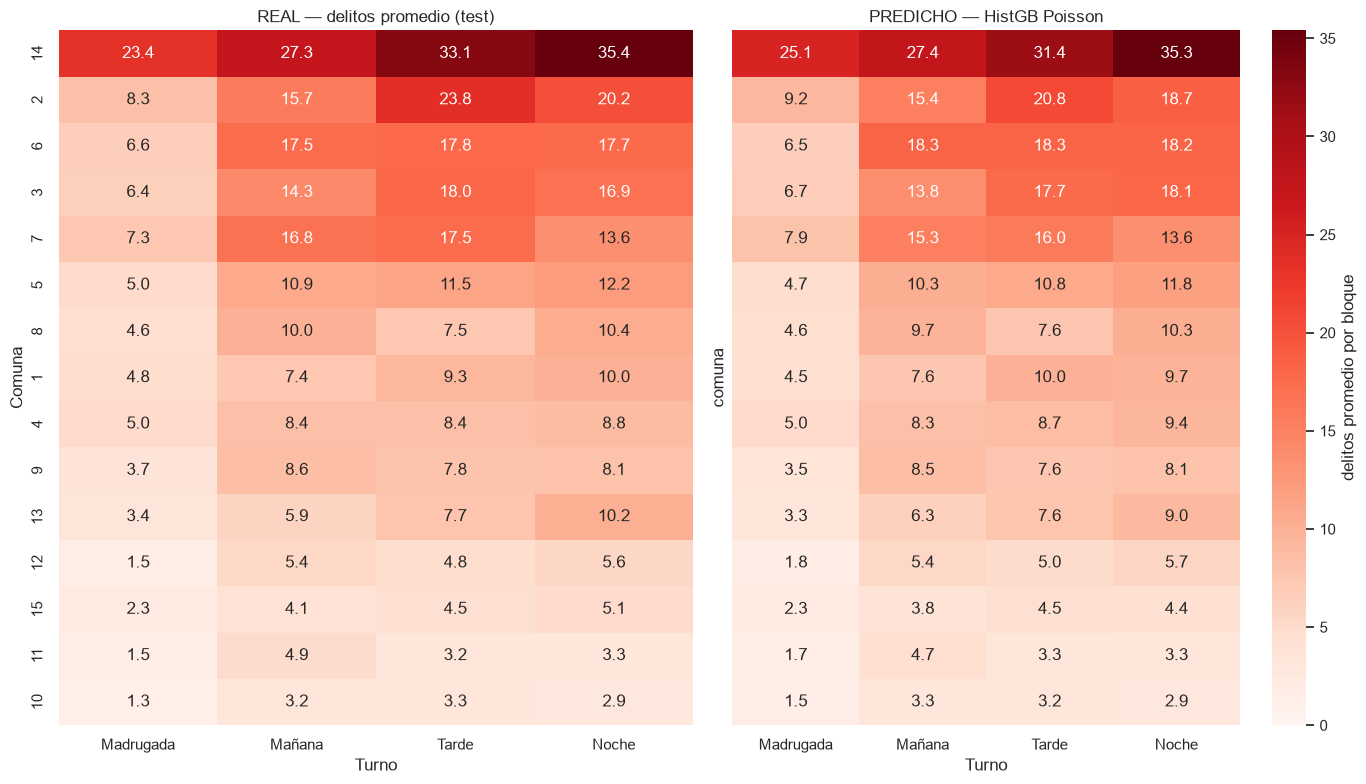

In [12]:
# Heatmap REAL vs PREDICHO
df_eval = X_test.copy()
df_eval['real'] = y_test.values
df_eval['pred'] = np.clip(mejor_modelo_reg.predict(X_test), 0, None)

orden_turnos = ['Madrugada', 'Mañana', 'Tarde', 'Noche']
piv_real = df_eval.pivot_table(index='comuna', columns='turno', values='real', aggfunc='mean').reindex(columns=orden_turnos)
piv_pred = df_eval.pivot_table(index='comuna', columns='turno', values='pred', aggfunc='mean').reindex(columns=orden_turnos)

# mismo orden de comunas en ambos (según el real) y misma escala de color
orden_filas = piv_real.mean(axis=1).sort_values(ascending=False).index
piv_real, piv_pred = piv_real.loc[orden_filas], piv_pred.loc[orden_filas]
vmax = float(max(piv_real.max().max(), piv_pred.max().max()))

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
sns.heatmap(piv_real, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=vmax, ax=axes[0], cbar=False)
axes[0].set_title('REAL — delitos promedio (test)')
sns.heatmap(piv_pred, annot=True, fmt='.1f', cmap='Reds', vmin=0, vmax=vmax, ax=axes[1],
            cbar_kws={'label': 'delitos promedio por bloque'})
axes[1].set_title(f'PREDICHO — {mejor_nombre_reg}')
for ax in axes:
    ax.set_xlabel('Turno')
axes[0].set_ylabel('Comuna')
plt.tight_layout()
plt.show()

### Importancia de variables (regresión)

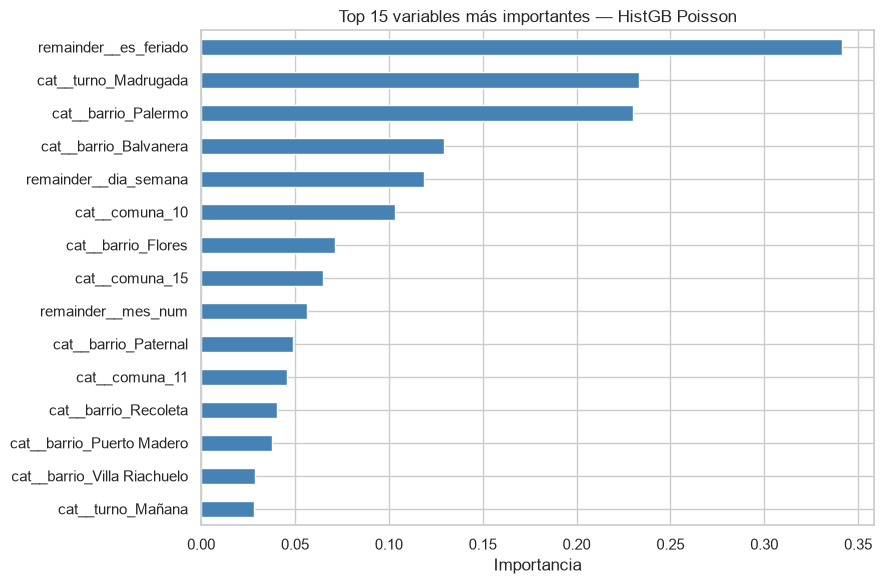

In [13]:
prep = mejor_modelo_reg.named_steps['prep']
modelo_final = mejor_modelo_reg.named_steps['model']
nombres = list(prep.get_feature_names_out())

if hasattr(modelo_final, 'feature_importances_'):
    importancias = pd.Series(modelo_final.feature_importances_, index=nombres)
else:
    Xt = prep.transform(X_test)
    perm = permutation_importance(modelo_final, Xt, y_test,
                                  n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
    importancias = pd.Series(perm.importances_mean, index=nombres)

importancias = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
importancias.iloc[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 15 variables más importantes — {mejor_nombre_reg}')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

---
## Enfoque 2 — Clasificación: alto vs. bajo riesgo

Sobre el mismo dataset, predecimos si una combinación de contexto corresponde a **alto riesgo** (`cantidad` por encima de la mediana) o **bajo riesgo**. Comparamos **Random Forest**, **SVM** y **HistGradientBoosting**, con `GridSearchCV` y `F1` como métrica de optimización (más adecuada que accuracy ante posible desbalance).

In [14]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
print('Train:', Xc_train.shape, ' Test:', Xc_test.shape)

Train: (32614, 8)  Test: (8154, 8)


### Entrenamiento con Random Forest Classifier

In [15]:
from sklearn.ensemble import RandomForestClassifier

pipe_rfc = Pipeline([('prep', preprocessor),
                     ('model', RandomForestClassifier(random_state=RANDOM_STATE))])

param_grid_rfc = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20]
}

grid_rfc = GridSearchCV(pipe_rfc, param_grid_rfc, cv=3, scoring='f1', n_jobs=-1)
grid_rfc.fit(Xc_train, yc_train)
print('Mejores hiperparámetros (RF Classifier):', grid_rfc.best_params_)
print('F1 CV (train):', grid_rfc.best_score_)

Mejores hiperparámetros (RF Classifier): {'model__max_depth': 20, 'model__n_estimators': 200}
F1 CV (train): 0.8606787498912557


### Entrenamiento con SVM

In [16]:
from sklearn.svm import SVC

pipe_svm = Pipeline([('prep', preprocessor),
                     ('model', SVC(probability=True, random_state=RANDOM_STATE))])

param_grid_svm = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=3, scoring='f1', n_jobs=-1)
grid_svm.fit(Xc_train, yc_train)
print('Mejores hiperparámetros (SVM):', grid_svm.best_params_)
print('F1 CV (train):', grid_svm.best_score_)

Mejores hiperparámetros (SVM): {'model__C': 10, 'model__kernel': 'rbf'}
F1 CV (train): 0.8642693775135021


### Entrenamiento con HistGradientBoosting Classifier


In [17]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Gradient Boosting por histogramas: rápido y serializable (sin FunctionTransformer).
pipe_hgbc = Pipeline([('prep', preprocessor_dense),
                      ('model', HistGradientBoostingClassifier(
                          random_state=RANDOM_STATE,
                          early_stopping=True, validation_fraction=0.1))])

param_grid_hgbc = {
    'model__learning_rate':    [0.05, 0.1],
    'model__max_leaf_nodes':   [31, 63],
    'model__max_iter':         [300, 600],
    'model__l2_regularization':[0.0, 1.0],
}

grid_hgbc = GridSearchCV(pipe_hgbc, param_grid_hgbc, cv=3, scoring='f1', n_jobs=-1)
grid_hgbc.fit(Xc_train, yc_train)
print('Mejores hiperparámetros (HistGB Classifier):', grid_hgbc.best_params_)
print('F1 CV (train):', grid_hgbc.best_score_)

Mejores hiperparámetros (HistGB Classifier): {'model__l2_regularization': 0.0, 'model__learning_rate': 0.05, 'model__max_iter': 300, 'model__max_leaf_nodes': 63}
F1 CV (train): 0.869094761467942


### Comparación y selección del modelo de clasificación

In [18]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluar_clf(modelo, nombre):
    pred = modelo.predict(Xc_test)
    return {'Modelo': nombre,
            'Accuracy': accuracy_score(yc_test, pred),
            'Precision': precision_score(yc_test, pred),
            'Recall': recall_score(yc_test, pred),
            'F1': f1_score(yc_test, pred)}

# Todos los candidatos de clasificación (incluye SVM cíclico y HistGB)
modelos_clf = {
    'Random Forest':  grid_rfc.best_estimator_,
    'SVM':            grid_svm.best_estimator_,
    'HistGB':         grid_hgbc.best_estimator_,
}

resultados_clf = pd.DataFrame(
    [evaluar_clf(m, n) for n, m in modelos_clf.items()]
).set_index('Modelo').round(4)
print(resultados_clf)

mejor_nombre_clf = resultados_clf['F1'].idxmax()
mejor_modelo_clf = modelos_clf[mejor_nombre_clf]
print(f'\nModelo de clasificación seleccionado: {mejor_nombre_clf}')

               Accuracy  Precision  Recall      F1
Modelo                                            
Random Forest    0.8628     0.8539  0.8703  0.8620
SVM              0.8701     0.8692  0.8668  0.8680
HistGB           0.8738     0.8744  0.8685  0.8715

Modelo de clasificación seleccionado: HistGB


### Métricas y matriz de confusión (Clasificacion)

Reporte de clasificación:
              precision    recall  f1-score   support

 Bajo riesgo       0.87      0.88      0.88      4138
 Alto riesgo       0.87      0.87      0.87      4016

    accuracy                           0.87      8154
   macro avg       0.87      0.87      0.87      8154
weighted avg       0.87      0.87      0.87      8154



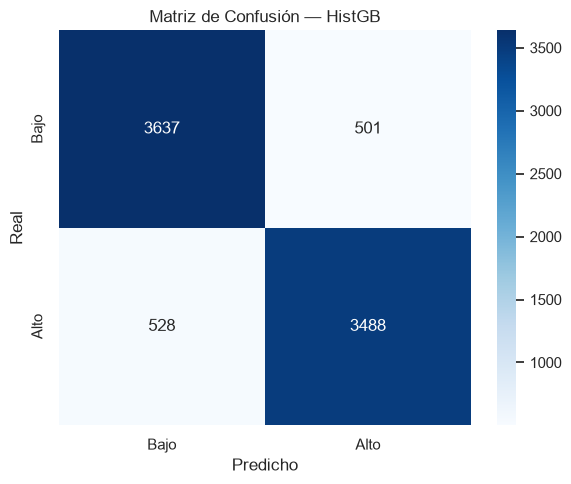

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

yc_pred = mejor_modelo_clf.predict(Xc_test)
print('Reporte de clasificación:')
print(classification_report(yc_test, yc_pred, target_names=['Bajo riesgo', 'Alto riesgo']))

cm = confusion_matrix(yc_test, yc_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo', 'Alto'], yticklabels=['Bajo', 'Alto'], ax=ax)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión — {mejor_nombre_clf}')
plt.tight_layout()
plt.show()

---
## Análisis de los resultados
### Regresión
El enfoque de Regresión determinó como apropiado al modelo **HistGradientBoosting con pérdida de Poisson**, que superó tanto a Random Forest (MAE 2.6142) como a Gradient Boosting (MAE 2.4116).

Obtuvo un MAE de 2.2250, lo que significa que el modelo erró, en promedio, por aproximadamente 2.2 delitos en sus predicciones por bloque espacio-temporal. Considerando que los datos cuentan con una mediana de 4 delitos, se lo considera un error aceptable. Además, al usar pérdida de Poisson (con *link* logarítmico), las predicciones son no negativas por construcción, lo cual es coherente con el hecho de que la cantidad de delitos es un conteo.

Obtuvo un RMSE de 3.4935. Al ser mayor que el MAE, nos indica que el modelo comete algunos errores más grandes en ciertos bloques (penaliza más los valores atípicos), lo cual es normal en zonas con picos drásticos de criminalidad (como comunas céntricas en turnos específicos).

Obtuvo un $R^2$ de 0.8316, por lo que las variables de contexto elegidas (barrio, comuna, año, turno, día, feriado) logran explicar el 83.2% de la variabilidad de la cantidad de delitos en la Ciudad de Buenos Aires.

###Clasificación
Por otro lado, en el enfoque de Clasificación se determinó como apropiado al modelo **HistGradientBoosting**, que quedó por encima del SVM (F1 0.8680) y del Random Forest (F1 0.8616).

Dado el balance del dataset, 50.7% bajo riesgo vs 49.3% alto riesgo, validamos los resultados por medio de un Accuracy que resultó de 87.38%. El modelo acierta casi 9 de cada 10 predicciones de riesgo.

Precision (87.44%) vs. Recall (86.85%): Esta relación es vital para la seguridad pública.
El Recall nos indicó que el modelo es capaz de detectar el 86.9% de todas las zonas que realmente van a ser de Alto Riesgo, con un 13.1% de falsos negativos.
Por otro lado, la precisión indicó que cuando el modelo emite una alerta de "Alto Riesgo", tiene un 87.44% de probabilidad de ser real, minimizando el envío inútil de patrulleros a zonas tranquilas (falsos positivos).

Este equilibrio se evidencia en el F1-Score de 87.15%.

### Validación en un año no visto (2024)
Para medir la **generalización temporal** evaluamos los modelos (entrenados con 2022–2023) sobre **2024**, un año que nunca vieron:

- **Regresión:** MAE 2.59, RMSE 4.27, $R^2$ 0.7745. Hay una caída moderada respecto del test ($R^2$ 0.83 → 0.77), esperable al predecir un período futuro, pero el modelo sigue explicando ~77% de la variabilidad.
- **Clasificación:** Accuracy 87.02%, Precision 88.09%, Recall 87.21%, F1 87.65% — prácticamente idéntico (incluso levemente superior) al test.

Esto confirma que el modelo **no está sobreajustado al período de entrenamiento**: mantiene un desempeño comparable sobre un año nuevo, en especial en la tarea de clasificación de riesgo, que es la de uso operativo.

---
## Persistencia de los modelos

Guardamos **ambos** modelos seleccionados (incluyen el preprocesamiento dentro del `Pipeline`) en formato `.joblib`, de modo que puedan cargarse luego **sin reentrenamiento** para su integración en el siguiente entregable.

In [20]:
import joblib, sklearn

joblib.dump(mejor_modelo_reg, 'modelo_regresion_delitos.joblib')
joblib.dump(mejor_modelo_clf, 'modelo_clasificacion_riesgo.joblib')

metadata = {
    'features': features,                               # columnas EXACTAS que espera el modelo (incluye 'anio')
    'categoricas': categoricas,
    'numericas': numericas,
    'umbral_clasificacion': float(umbral),              # mediana usada para binarizar el target
    'modelo_regresion': mejor_nombre_reg,
    'modelo_clasificacion': mejor_nombre_clf,
    'anios_entrenamiento': sorted(int(a) for a in df_final['anio'].unique()),
    'sklearn_version': sklearn.__version__,
}
joblib.dump(metadata, 'metadata_modelos.joblib')

print('Modelos guardados:')
print(' - modelo_regresion_delitos.joblib   (', mejor_nombre_reg, ')')
print(' - modelo_clasificacion_riesgo.joblib (', mejor_nombre_clf, ')')
print(' - metadata_modelos.joblib')
print('Entrenado con años:', metadata['anios_entrenamiento'], '| sklearn', metadata['sklearn_version'])

Modelos guardados:
 - modelo_regresion_delitos.joblib   ( HistGB Poisson )
 - modelo_clasificacion_riesgo.joblib ( HistGB )
 - metadata_modelos.joblib
Entrenado con años: [2022, 2023] | sklearn 1.5.2


### Verificación de carga (sin reentrenamiento)

In [21]:
import joblib

modelo_reg_cargado = joblib.load('modelo_regresion_delitos.joblib')
modelo_clf_cargado = joblib.load('modelo_clasificacion_riesgo.joblib')
meta = joblib.load('metadata_modelos.joblib')

# Predecimos VARIOS ejemplos del test (con las columnas EXACTAS que espera el modelo, incluye 'anio')
n = 10
ejemplos = X_test.iloc[:n][meta['features']]
real_cantidad = y_test.iloc[:n].to_numpy()

# Regresión: predicho vs real (clip a 0; HistGB Poisson ya es no negativo)
pred_cantidad = np.clip(modelo_reg_cargado.predict(ejemplos), 0, None)

# Clasificación: predicho (umbral por defecto 0.5) vs real
proba      = modelo_clf_cargado.predict_proba(ejemplos)[:, 1]
pred_clase = modelo_clf_cargado.predict(ejemplos)
real_clase = (real_cantidad > meta['umbral_clasificacion']).astype(int)

comparacion = ejemplos.copy()
comparacion['cant_real']   = real_cantidad
comparacion['cant_pred']   = pred_cantidad.round(2)
comparacion['error_abs']   = np.abs(pred_cantidad - real_cantidad).round(2)
comparacion['riesgo_real'] = np.where(real_clase == 1, 'Alto', 'Bajo')
comparacion['riesgo_pred'] = np.where(pred_clase == 1, 'Alto', 'Bajo')
comparacion['P_alto']      = proba.round(2)

print('MAE de esta muestra        :', round(float(np.mean(np.abs(pred_cantidad - real_cantidad))), 3))
print('Aciertos de clasificación  :', f'{int((pred_clase == real_clase).sum())}/{n}')
print('Entrenado con años:', meta['anios_entrenamiento'], '| sklearn', meta['sklearn_version'])
print('\n(un único ejemplo no valida el modelo; eso lo hacen las métricas de test)')
comparacion

MAE de esta muestra        : 1.971
Aciertos de clasificación  : 10/10
Entrenado con años: [2022, 2023] | sklearn 1.5.2

(un único ejemplo no valida el modelo; eso lo hacen las métricas de test)


,barrio,comuna,anio,dia_semana,mes_num,turno,es_fin_de_semana,es_feriado,cant_real,cant_pred,error_abs,riesgo_real,riesgo_pred,P_alto
8132,Parque Patricios,4,2022,5,3,Tarde,True,False,8.0,5.91,2.09,Alto,Alto,0.61
30149,Villa Urquiza,12,2023,2,4,Noche,False,False,9.0,11.03,2.03,Alto,Alto,0.97
31594,Villa Del Parque,11,2022,6,12,Mañana,True,True,0.0,0.86,0.86,Bajo,Bajo,0.01
14019,Parque Chacabuco,7,2022,6,5,Madrugada,True,False,8.0,5.77,2.23,Alto,Alto,0.67
29561,Floresta,10,2022,3,1,Noche,False,False,4.0,4.52,0.52,Bajo,Bajo,0.45
17612,Flores,7,2023,0,2,Tarde,False,False,22.0,18.26,3.74,Alto,Alto,0.99
2296,San Telmo,1,2022,0,6,Tarde,False,False,1.0,4.56,3.56,Bajo,Bajo,0.43
28233,Parque Chas,15,2022,4,10,Noche,False,True,1.0,0.38,0.62,Bajo,Bajo,0.01
35787,Monte Castro,10,2023,0,6,Madrugada,False,True,0.0,0.46,0.46,Bajo,Bajo,0.00
16063,Villa Soldati,8,2023,4,9,Madrugada,False,False,1.0,4.60,3.60,Bajo,Bajo,0.48


---
## Validación en un año no visto (2024)

Prueba de **generalización temporal**: el modelo se entrenó con 2022–2023 y aquí lo evaluamos sobre **2024**, un año que nunca vio. Es una validación más exigente y honesta que el `train_test_split` aleatorio (que mezcla años), porque mide si el modelo sirve para **predecir un período futuro**.

Replicamos sobre 2024 exactamente el mismo preprocesamiento y armado de grilla, y usamos el **mismo umbral de clasificación** del entrenamiento para definir el target real. *Nota:* como `anio` entra como variable numérica y los árboles no extrapolan, 2024 se trata internamente como el año más reciente visto; el poder predictivo proviene del resto del contexto (barrio, comuna, turno, calendario).

In [23]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, f1_score, precision_score, recall_score)

URL_2024 = 'https://drive.google.com/file/d/1Ydr5-h05KACsywsk7FuGhXkSyb6jIU1f/view?usp=sharing'

def preparar_df_final(df_raw):
    d = df_raw.drop(columns=['dia', 'cantidad']).copy()
    d['fecha'] = pd.to_datetime(d['fecha'])
    d['dia_semana'] = d['fecha'].dt.dayofweek
    d['latitud']  = pd.to_numeric(d['latitud'],  errors='coerce').replace(0.0, np.nan)
    d['longitud'] = pd.to_numeric(d['longitud'], errors='coerce').replace(0.0, np.nan)
    for col in ['mes', 'tipo', 'subtipo', 'barrio']:
        d[col] = d[col].str.strip().str.title()
    d['mes_num'] = d['mes'].map(meses)
    d['turno'] = d['franja'].apply(franja_a_turno)
    d['es_fin_de_semana'] = d['fecha'].dt.dayofweek >= 5
    d = d[d['latitud'].notna() & d['longitud'].notna() &
          d['barrio'].notna() & d['comuna'].notna() & d['turno'].notna()].copy()
    hol = {}
    for a in sorted(d['anio'].unique()):
        try:    hol.update(get_ar_holidays_full(int(a)))
        except Exception as e: print('Sin feriados para', a, ':', e)
    d['es_feriado'] = d['fecha'].dt.strftime('%Y-%m-%d').isin(hol)
    bc  = d[['barrio', 'comuna']].drop_duplicates()
    ctx = d[['anio', 'dia_semana', 'mes_num', 'es_fin_de_semana', 'es_feriado']].drop_duplicates()
    tur = pd.DataFrame({'turno': d['turno'].unique()})
    full = bc.merge(ctx, how='cross').merge(tur, how='cross')[group_cols]
    real = d.groupby(group_cols).size().reset_index(name='cantidad')
    out = full.merge(real, on=group_cols, how='left')
    out['cantidad'] = out['cantidad'].fillna(0)
    return out

if URL_2024:
    gdown.download(URL_2024, 'delitos_2024.csv', quiet=False)
df_2024_raw = pd.read_csv('delitos_2024.csv', dtype={'barrio': str, 'comuna': str}).drop(columns=['id-mapa'])

df_final_2024 = preparar_df_final(df_2024_raw)
X_2024 = df_final_2024[meta['features']]
y_2024 = df_final_2024['cantidad'].to_numpy()
print('df_final_2024:', df_final_2024.shape)

# --- Regresión sobre 2024 ---
pred_2024 = np.clip(modelo_reg_cargado.predict(X_2024), 0, None)
print('\n=== Regresión en 2024 (año no visto) ===')
print(f'MAE  = {mean_absolute_error(y_2024, pred_2024):.4f}')
print(f'RMSE = {np.sqrt(mean_squared_error(y_2024, pred_2024)):.4f}')
print(f'R2   = {r2_score(y_2024, pred_2024):.4f}')

# --- Clasificación sobre 2024 (target con el MISMO umbral del entrenamiento) ---
yc_2024    = (y_2024 > meta['umbral_clasificacion']).astype(int)
predc_2024 = modelo_clf_cargado.predict(X_2024)
print('\n=== Clasificación en 2024 (año no visto) ===')
print(f'Accuracy  = {accuracy_score(yc_2024, predc_2024):.4f}')
print(f'Precision = {precision_score(yc_2024, predc_2024):.4f}')
print(f'Recall    = {recall_score(yc_2024, predc_2024):.4f}')
print(f'F1        = {f1_score(yc_2024, predc_2024):.4f}')

Downloading...
From: https://drive.google.com/uc?id=1Ydr5-h05KACsywsk7FuGhXkSyb6jIU1f
To: /Users/patricktoralschi/Desktop/ciencia-datos/delitos_2024.csv
100%|██████████| 20.3M/20.3M [00:00<00:00, 26.3MB/s]


df_final_2024: (19776, 9)

=== Regresión en 2024 (año no visto) ===
MAE  = 2.5902
RMSE = 4.2714
R2   = 0.7745

=== Clasificación en 2024 (año no visto) ===
Accuracy  = 0.8702
Precision = 0.8809
Recall    = 0.8721
F1        = 0.8765


### Comparación de desempeño: test vs 2024
Contrastamos las métricas sobre el conjunto de test (2022–2023) contra las del año no visto (2024). Si las barras quedan parejas, el modelo **generaliza** a un período futuro; las diferencias indican cuánto se degrada al enfrentar datos nuevos.

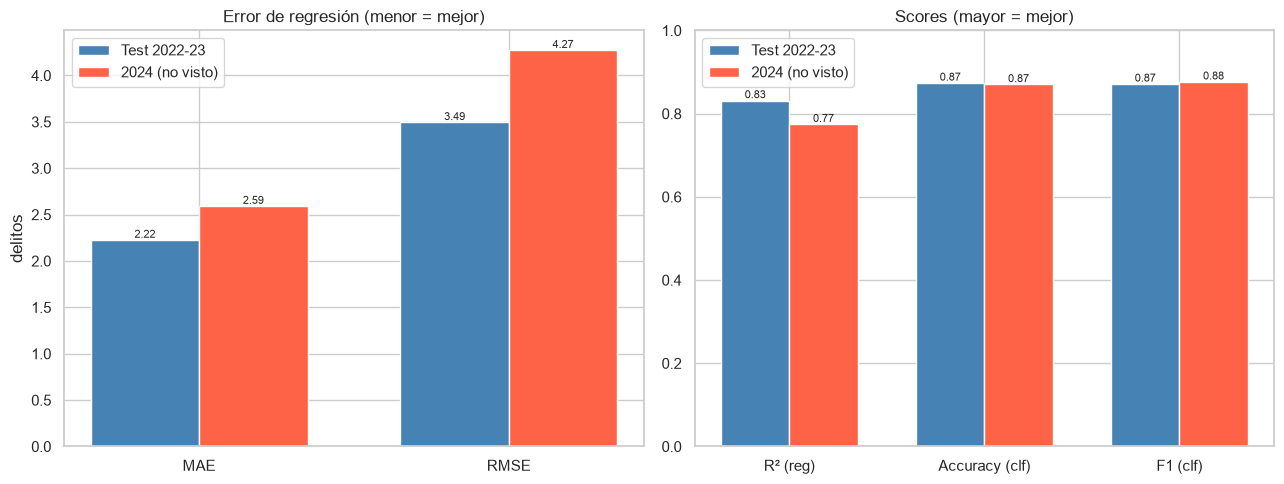

Exception ignored in: <function ResourceTracker.__del__ at 0x10134eac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1056b6ac0>
Traceback (most recent call last):
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/patricktoralschi/.local/share/uv/python/cpython-3.13.7-macos-aarch64-n

In [24]:
# Comparación visual de desempeño: test (2022-2023) vs año no visto (2024)
# Métricas de test (recalculadas sobre el mejor modelo de cada tarea)
pred_test_reg = np.clip(mejor_modelo_reg.predict(X_test), 0, None)
mae_test, rmse_test = mean_absolute_error(y_test, pred_test_reg), np.sqrt(mean_squared_error(y_test, pred_test_reg))
r2_test = r2_score(y_test, pred_test_reg)
pred_test_clf = mejor_modelo_clf.predict(Xc_test)
acc_test, f1_test = accuracy_score(yc_test, pred_test_clf), f1_score(yc_test, pred_test_clf)

# Métricas 2024 (reusa pred_2024 / yc_2024 / predc_2024 de la celda anterior)
mae_24, rmse_24 = mean_absolute_error(y_2024, pred_2024), np.sqrt(mean_squared_error(y_2024, pred_2024))
r2_24 = r2_score(y_2024, pred_2024)
acc_24, f1_24 = accuracy_score(yc_2024, predc_2024), f1_score(yc_2024, predc_2024)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
w = 0.35

# Errores de regresión (escala "delitos")
x = np.arange(2)
axes[0].bar(x - w/2, [mae_test, rmse_test], w, label='Test 2022-23', color='steelblue')
axes[0].bar(x + w/2, [mae_24, rmse_24],     w, label='2024 (no visto)', color='tomato')
axes[0].set_xticks(x); axes[0].set_xticklabels(['MAE', 'RMSE'])
axes[0].set_ylabel('delitos'); axes[0].set_title('Error de regresión (menor = mejor)'); axes[0].legend()

# Scores 0-1 (R2 de regresión, Accuracy y F1 de clasificación)
x2 = np.arange(3)
axes[1].bar(x2 - w/2, [r2_test, acc_test, f1_test], w, label='Test 2022-23', color='steelblue')
axes[1].bar(x2 + w/2, [r2_24, acc_24, f1_24],       w, label='2024 (no visto)', color='tomato')
axes[1].set_xticks(x2); axes[1].set_xticklabels(['R² (reg)', 'Accuracy (clf)', 'F1 (clf)'])
axes[1].set_ylim(0, 1); axes[1].set_title('Scores (mayor = mejor)'); axes[1].legend()
for ax in axes:
    for c in ax.containers:
        ax.bar_label(c, fmt='%.2f', fontsize=8)

plt.tight_layout()
plt.show()

---
## Cierre de la entrega: Reflexiones finales

La experimentación demostró que la combinación de variables espacio-temporales básicas enriquecidas con el calendario de feriados nacionales posee un alto poder predictivo.

En la regresión, el **HistGradientBoosting con pérdida de Poisson** resultó el modelo más ajustado ($R^2 \approx 0.83$): al tratar la variable objetivo como un conteo entrega predicciones no negativas y mejora el MAE respecto de Random Forest y Gradient Boosting.

En clasificación, el **HistGradientBoosting** también resultó el mejor (F1 ≈ 0.87), por encima del SVM y del Random Forest, con un balance muy parejo entre precisión y recall y a un costo de cómputo mucho menor que el SVM.

Respecto del armado del dataset, la grilla de contextos se completó con ceros **únicamente para combinaciones espacio-temporales plausibles** (pares barrio–comuna reales y contextos de calendario coherentes), evitando inflar el conjunto con combinaciones imposibles. De este modo se incorporan escenarios de no ocurrencia de forma realista, manteniendo un balance razonable del target (~51% bajo / ~49% alto riesgo).

Para validar la **capacidad de predecir un período futuro** realizamos una **prueba sobre 2024**, un año no usado en el entrenamiento. El modelo generalizó bien: la clasificación de riesgo mantuvo su desempeño (F1 ≈ 0.88, prácticamente igual al test) y la regresión sufrió una caída moderada y esperable ($R^2$ 0.83 → 0.77). Esto indica que el modelo no está sobreajustado al período de entrenamiento y resulta utilizable para anticipar la concentración de delitos en años siguientes, con la salvedad de re-entrenar periódicamente para absorber cambios en los patrones.

En cuanto a la escalabilidad, dado que el HistGradientBoosting domina ambas tareas a bajo costo de cómputo, sería el candidato preferible si el dataset creciera; también podrían ensayarse arquitecturas como XGBoost o LightGBM.

En conclusión, el modelo estima la intensidad promedio esperada de delitos en un contexto espacio-temporal agregado, y su señal de riesgo alto/bajo se mantiene estable al proyectarse sobre un año nuevo.